In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash")

class resume(TypedDict):
    
    resume: str 
    jd: str
    skill: list
    aim: str
    cgpa: int
    exp: int
    score: int
    weak_areas: list
    max_iterr: int

In [ ]:
def info(state :resume)->resume:
  #    messages = [
  #           SystemMessage(content="You are a technical expert and want to hire a qualified candidate based upon the resume details."),
  #           HumanMessage(content=f"""
  #  review the resume details : "{state['resume']}", "{state['jd']}","{state['skill']}","{state['aim']}","{state['cgpa']}","{state['exp']}","{state['score']}".""")]

  #    response=model.invoke(messages)
  #    print(response.content)
     return {'resume':state['resume'],'jd':state['jd'],'skill':state['skill'],'aim':state['aim'],'cgpa':state['cgpa'],'exp':state['exp'],'score':state['score']}
     


In [ ]:
def skill(state:resume)->resume:
    resume=state['resume']
    jd=state['jd']
    messages=[
        SystemMessage(content="You are a technical expert and want to hire a qualified candidate based upon the resume details."),
        HumanMessage(content=f"""You need to find the similarity match in the the resume skills mentioned {resume} and from the {jd} """ )
    ]
    response=model.invoke(messages)
    return 







In [ ]:



def experience(state):
    print("EXPERIENCE")
    return {}

def ed(state):
    print("EDUCATION")
    return {}
def score(state):
    print("CALCULATING SCORE")
    return {"score": 60}

def run(state):
    print("RUNNING DIAGNOSIS")
    return {"weak_areas": ["skills", "experience"]}

def improve_resume(state):
    print("IMPROVING RESUME")
    return state

def route_evaluation(state):
    if state["score"] < 75:
        return "needs_improvement"

    return "approved"

def check_score(state):
    if state["score"] < 75:
        return "low"
    
    return "good"

In [8]:
graph=StateGraph(resume)
graph.add_node('info',info)
graph.add_node('skillmatch',skill)
graph.add_node('experience',experience)
graph.add_node('education',ed)
graph.add_node('calculate_score',score)
graph.add_node('rundiagnosis',run)
graph.add_node('improve_resume',improve_resume)


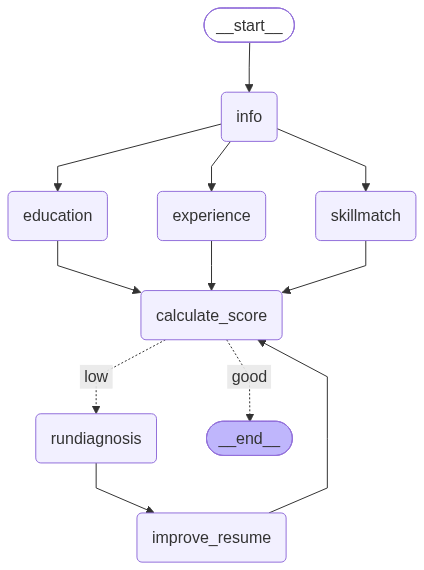

In [9]:
graph.add_edge(START, "info")

graph.add_edge("info", "skillmatch")
graph.add_edge("info", "experience")
graph.add_edge("info", "education")

graph.add_edge("skillmatch", "calculate_score")
graph.add_edge("experience", "calculate_score")
graph.add_edge("education", "calculate_score")

graph.add_conditional_edges(
    "calculate_score",
    check_score,
    {
        "low": "rundiagnosis",
        "good": END
    }
)

graph.add_edge("rundiagnosis", "improve_resume")

graph.add_edge("improve_resume", "calculate_score")

workflow=graph.compile()
workflow


In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)




class Resume(TypedDict):
    resume: str
    jd: str

    required_skills: list
    matched_skills: list
    missing_skills: list

    aim: str

    candidate_cgpa: float
    required_cgpa: float

    candidate_exp: float
    required_exp: float

    skill_match: int
    experience_match: int
    education_match: int

    score: int
    weak_areas: list

    max_iterr: int
    iteration: int




class InfoOutput(BaseModel):
    aim: str = Field(
        description="Main job role from the job description"
    )

    required_cgpa: float = Field(
        description="Minimum required CGPA. Return 0 if not mentioned."
    )

    required_exp: float = Field(
        description="Required years of experience. Return 0 if not mentioned."
    )


class SkillOutput(BaseModel):
    required_skills: list[str] = Field(
        description="Important technical skills required by the JD"
    )


class ExperienceOutput(BaseModel):
    candidate_exp: float = Field(
        description="Candidate's relevant years of experience"
    )


class EducationOutput(BaseModel):
    degree_match: int = Field(
        description="Degree/field match from 0 to 100"
    )


class DiagnosisOutput(BaseModel):
    weak_areas: list[str]


class ImprovedResume(BaseModel):
    resume: str




def info(state):

    prompt = f"""
Analyze this Job Description.

JOB DESCRIPTION:
{state["jd"]}

Extract:

1. Main job role.
2. Minimum CGPA required.
3. Required years of experience.

If CGPA is not mentioned, return 0.

If experience is not mentioned, return 0.
"""

    structured_model = model.with_structured_output(InfoOutput)

    result = structured_model.invoke(prompt)

    return {
        "aim": result.aim,
        "required_cgpa": result.required_cgpa,
        "required_exp": result.required_exp
    }



def skill(state):

    prompt = f"""
Analyze the Job Description and identify the important technical
skills required for the job.

JOB DESCRIPTION:
{state["jd"]}

Do not include generic words like:
communication, teamwork, leadership, hardworking.

Return only relevant technical skills.
"""

    structured_model = model.with_structured_output(SkillOutput)

    result = structured_model.invoke(prompt)

    resume_text = state["resume"].lower()

    matched = []
    missing = []

    for skill in result.required_skills:

        if skill.lower() in resume_text:
            matched.append(skill)
        else:
            missing.append(skill)

    return {
        "required_skills": result.required_skills,
        "matched_skills": matched,
        "missing_skills": missing,
        "skill_match": int(
            len(matched) / len(result.required_skills) * 100
        ) if result.required_skills else 100
    }



def experience(state):

    prompt = f"""
Analyze the candidate's resume.

RESUME:
{state["resume"]}

Find the total relevant professional experience
in years.

Only count actual internships/jobs/work experience.

Do not count college projects as professional experience.
"""

    structured_model = model.with_structured_output(ExperienceOutput)

    result = structured_model.invoke(prompt)

    candidate_exp = result.candidate_exp
    required_exp = state["required_exp"]

    if required_exp == 0:
        experience_match = 100

    elif candidate_exp >= required_exp:
        experience_match = 100

    elif candidate_exp == 0:
        experience_match = 0

    else:
        experience_match = int(
            candidate_exp / required_exp * 100
        )

    return {
        "candidate_exp": candidate_exp,
        "experience_match": experience_match
    }




def ed(state):

    prompt = f"""
Analyze the candidate's education against the job description.

JOB DESCRIPTION:
{state["jd"]}

RESUME:
{state["resume"]}

Determine how well the candidate's degree/field matches
the educational requirements.

Return:

100 = completely relevant
75 = mostly relevant
50 = partially relevant
0 = not relevant
"""

    structured_model = model.with_structured_output(EducationOutput)

    result = structured_model.invoke(prompt)

    candidate_cgpa = state["candidate_cgpa"]
    required_cgpa = state["required_cgpa"]

    cgpa_match = 100

    if required_cgpa > 0:

        if candidate_cgpa >= required_cgpa:
            cgpa_match = 100
        else:
            cgpa_match = int(
                candidate_cgpa / required_cgpa * 100
            )

    education_match = int(
        result.degree_match * 0.6 +
        cgpa_match * 0.4
    )

    return {
        "education_match": education_match
    }




def score(state):

    skill_score = state["skill_match"]

    experience_score = state["experience_match"]

    education_score = state["education_match"]

    final_score = int(
        skill_score * 0.40 +
        experience_score * 0.35 +
        education_score * 0.25
    )

    print("\nSKILL SCORE:", skill_score)
    print("EXPERIENCE SCORE:", experience_score)
    print("EDUCATION SCORE:", education_score)
    print("FINAL SCORE:", final_score)

    return {
        "score": final_score
    }


# =========================
# DIAGNOSIS
# =========================

def run(state):

    weak_areas = []

    if state["skill_match"] < 75:
        weak_areas.append(
            "Missing skills: " +
            ", ".join(state["missing_skills"])
        )

    if state["experience_match"] < 75:
        weak_areas.append(
            "Insufficient relevant experience"
        )

    if state["education_match"] < 75:
        weak_areas.append(
            "Education does not fully match the job requirements"
        )

    if not weak_areas:
        weak_areas.append(
            "Resume needs better keyword alignment"
        )

    return {
        "weak_areas": weak_areas
    }


# =========================
# IMPROVE RESUME
# =========================

def improve_resume(state):

    prompt = f"""
Improve this resume for the given job description.

JOB DESCRIPTION:
{state["jd"]}

CURRENT RESUME:
{state["resume"]}

WEAK AREAS:
{state["weak_areas"]}

MISSING SKILLS:
{state["missing_skills"]}

RULES:

1. Do not invent experience.
2. Do not invent internships.
3. Do not invent projects.
4. Do not invent skills the candidate does not have.
5. Do not change CGPA.
6. Do not create fake achievements.
7. Improve wording and keyword alignment.
8. Highlight existing relevant skills.
9. Make experience descriptions stronger.
10. Keep the resume professional and concise.

Return the complete improved resume.
"""

    structured_model = model.with_structured_output(
        ImprovedResume
    )

    result = structured_model.invoke(prompt)

    return {
        "resume": result.resume,
        "iteration": state["iteration"] + 1
    }


# =========================
# ROUTER
# =========================

def check_score(state):

    if state["score"] >= 75:
        return "good"

    if state["iteration"] >= state["max_iterr"]:
        return "stop"

    return "low"


# =========================
# GRAPH
# =========================

graph = StateGraph(Resume)

graph.add_node("info", info)
graph.add_node("skillmatch", skill)
graph.add_node("experience", experience)
graph.add_node("education", ed)
graph.add_node("calculate_score", score)
graph.add_node("rundiagnosis", run)
graph.add_node("improve_resume", improve_resume)


graph.add_edge(START, "info")


graph.add_edge("info", "skillmatch")
graph.add_edge("info", "experience")
graph.add_edge("info", "education")


graph.add_edge(
    "skillmatch",
    "calculate_score"
)

graph.add_edge(
    "experience",
    "calculate_score"
)

graph.add_edge(
    "education",
    "calculate_score"
)


graph.add_conditional_edges(
    "calculate_score",
    check_score,
    {
        "low": "rundiagnosis",
        "good": END,
        "stop": END
    }
)


graph.add_edge(
    "rundiagnosis",
    "improve_resume"
)

graph.add_edge(
    "improve_resume",
    "info"
)


workflow = graph.compile()

print(workflow)
print("checking the state")

initial_state = {

    "resume": """
Atharva Tiwari

B.Tech Electronics Engineering
Kamla Nehru Institute of Technology

Skills:
Python, C++, Java, JavaScript, SQL
React, FastAPI, Flask
Machine Learning, Deep Learning
TensorFlow, PyTorch
Git, Docker

Experience:
Frontend Intern

Worked on frontend development using React.
Built web interfaces and integrated APIs.
""",

    "jd": """
Python Developer

Requirements:

- Strong Python programming
- FastAPI
-Flask
- SQL
- REST API development
- Machine Learning knowledge
- Bachelor's degree in Computer Science,
  Electronics or related field
- 1 year of experience preferred
- Minimum CGPA 7.5
""",

    "required_skills": [],
    "matched_skills": [],
    "missing_skills": [],

    "aim": "",

    "candidate_cgpa": 9.77,
    "required_cgpa": 0,

    "candidate_exp": 0,
    "required_exp": 0,

    "skill_match": 0,
    "experience_match": 0,
    "education_match": 0,

    "score": 0,

    "weak_areas": [],

    "max_iterr": 2,
    "iteration": 0
}




result = workflow.invoke(initial_state)
print(result)

print("FINAL RESULT score")


print("\nRole:", result["aim"])

print("\nRequired Skills:")
print(result["required_skills"])

print("\nMatched Skills:")
print(result["matched_skills"])

print("\nMissing Skills:")
print(result["missing_skills"])

print("\nExperience Match:")
print(result["experience_match"])

print("\nEducation Match:")
print(result["education_match"])

print("\nFinal Score:")
print(result["score"])

print("\nWeak Areas:")
print(result["weak_areas"])

print("\nIterations:")
print(result["iteration"])

print("\nFinal Resume:")
print(result["resume"])

c:\Users\at499\100daysofml\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.



SKILL SCORE: 80
EXPERIENCE SCORE: 0
EDUCATION SCORE: 100
FINAL SCORE: 57


GoogleRateLimitError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 23.59629428s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 